# Análise Comparativa TCP vs R-UDP
**PPGCC/UFPI — Projeto de Redes de Computadores 2026-1**

**Aluno:** Manoel Messias Pereira Medeiros  
**Matrícula:** 20251014777  
**Data:** Maio/2026

---
### Cenários testados
| Cenário | Perda | Delay |
|---|---|---|
| A | 0% | 10 ms |
| B | 10% | 50 ms |
| C | 20% | 100 ms |

## Célula 1 — Instala dependências

In [ ]:

!pip install plotly seaborn pandas matplotlib -q

import plotly.io as pio

# Usa o renderer do Colab para mostrar os graficos
pio.renderers.default = 'colab'

# Funcao para salvar graficos Plotly sem kaleido
def salvar_plotly(fig, nome):
    nome_html = nome.replace('.png', '.html')
    fig.write_html(f'graficos/{nome_html}')
    print(f'Salvo: graficos/{nome_html}')

print('Pronto!')

Pronto!


## Célula 2 — Importações

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Pasta para salvar os graficos
import os
os.makedirs('graficos', exist_ok=True)

print('Bibliotecas carregadas!')

Bibliotecas carregadas!


## Célula 3 — Dados experimentais

In [ ]:
# Dados coletados nos experimentos
# protocolo | cenario | duracao(s) | throughput(Mbps) | bytes_total | retransmissoes
dados = [
    ['TCP',   'A\n(0%/10ms)',    0.0387,    2166.38,  10485760,    0],
    ['TCP',   'B\n(10%/50ms)',   0.0334,    2509.07,  10485760,    0],
    ['TCP',   'C\n(20%/100ms)', 483.729,       0.17,  10485760,    0],
    ['R-UDP', 'A\n(0%/10ms)',    0.2250,     372.90,  10485760,    0],
    ['R-UDP', 'B\n(10%/50ms)',  620.822,      0.200,  15525760, 3600],
    ['R-UDP', 'C\n(20%/100ms)',1345.906,      0.122,  20537040, 7180],
]

df = pd.DataFrame(dados, columns=[
    'protocolo', 'cenario', 'duracao_s',
    'throughput_mbps', 'bytes_total', 'retransmissoes'
])

# Metricas adicionais
df['overhead_bytes']  = df['bytes_total'] - 10485760
df['eficiencia_pct']  = (10485760 / df['bytes_total'] * 100).round(2)
df['perda_pct']       = [0, 10, 20, 0, 10, 20]
df['delay_ms']        = [10, 50, 100, 10, 50, 100]
df['cenario_label']   = ['A (0%/10ms)', 'B (10%/50ms)', 'C (20%/100ms)'] * 2

print('Dados carregados com sucesso!')
print()
print(df[['protocolo','cenario_label','duracao_s','throughput_mbps',
          'bytes_total','retransmissoes','eficiencia_pct']].to_string(index=False))

Dados carregados com sucesso!

protocolo cenario_label  duracao_s  throughput_mbps  bytes_total  retransmissoes  eficiencia_pct
      TCP   A (0%/10ms)     0.0387         2166.380     10485760               0          100.00
      TCP  B (10%/50ms)     0.0334         2509.070     10485760               0          100.00
      TCP C (20%/100ms)   483.7290            0.170     10485760               0          100.00
    R-UDP   A (0%/10ms)     0.2250          372.900     10485760               0          100.00
    R-UDP  B (10%/50ms)   620.8220            0.200     15525760            3600           67.54
    R-UDP C (20%/100ms)  1345.9060            0.122     20537040            7180           51.06


## Célula 4 — Gráfico 1: Throughput TCP vs R-UDP

In [ ]:
fig1 = px.bar(
    df, x='cenario_label', y='throughput_mbps', color='protocolo',
    barmode='group',
    title='<b>Gráfico 1 — Throughput: TCP vs R-UDP por Cenário</b>',
    labels={
        'throughput_mbps': 'Throughput (Mbps)',
        'cenario_label':   'Cenário',
        'protocolo':       'Protocolo'
    },
    color_discrete_map={'TCP': '#1565C0', 'R-UDP': '#D84315'},
    text='throughput_mbps'
)
fig1.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig1.update_layout(
    height=500, font_size=13,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    legend=dict(x=0.75, y=0.95)
)
fig1.show()
salvar_plotly(fig1, 'grafico1_throughput.png')
print('Salvo: graficos/grafico1_throughput.png')

Salvo: graficos/grafico1_throughput.html
Salvo: graficos/grafico1_throughput.png


## Célula 5 — Gráfico 2: Tempo de Transferência (escala log)

In [ ]:
fig2 = px.bar(
    df, x='cenario_label', y='duracao_s', color='protocolo',
    barmode='group', log_y=True,
    title='<b>Gráfico 2 — Tempo de Transferência (escala logarítmica)</b>',
    labels={
        'duracao_s':     'Tempo (s) — escala log',
        'cenario_label': 'Cenário',
        'protocolo':     'Protocolo'
    },
    color_discrete_map={'TCP': '#1565C0', 'R-UDP': '#D84315'},
    text='duracao_s'
)
fig2.update_traces(texttemplate='%{text:.3f}s', textposition='outside')
fig2.update_layout(
    height=500, font_size=13,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    legend=dict(x=0.01, y=0.95)
)
fig2.show()
salvar_plotly(fig2, 'grafico2_tempo.png')
print('Salvo: graficos/grafico2_tempo.png')

Salvo: graficos/grafico2_tempo.html
Salvo: graficos/grafico2_tempo.png


## Célula 6 — Gráfico 3: Retransmissões R-UDP

In [ ]:
df_rudp = df[df['protocolo'] == 'R-UDP'].copy()

fig3 = px.bar(
    df_rudp, x='cenario_label', y='retransmissoes',
    title='<b>Gráfico 3 — Retransmissões R-UDP por Cenário (Go-Back-N)</b>',
    labels={
        'retransmissoes': 'Número de Retransmissões',
        'cenario_label':  'Cenário'
    },
    color='cenario_label',
    color_discrete_sequence=['#43A047', '#FB8C00', '#E53935'],
    text='retransmissoes'
)
fig3.update_traces(textposition='outside')
fig3.update_layout(
    height=450, font_size=13,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey'),
    showlegend=False
)
fig3.show()
salvar_plotly(fig3, 'grafico3_retransmissoes.png')
print('Salvo: graficos/grafico3_retransmissoes.png')

Salvo: graficos/grafico3_retransmissoes.html
Salvo: graficos/grafico3_retransmissoes.png


## Célula 7 — Gráfico 4: Eficiência de Transmissão (%)

In [ ]:
fig4 = px.bar(
    df, x='cenario_label', y='eficiencia_pct', color='protocolo',
    barmode='group',
    title='<b>Gráfico 4 — Eficiência de Transmissão: bytes úteis / bytes totais (%)</b>',
    labels={
        'eficiencia_pct': 'Eficiência (%)',
        'cenario_label':  'Cenário',
        'protocolo':      'Protocolo'
    },
    color_discrete_map={'TCP': '#1565C0', 'R-UDP': '#D84315'},
    text='eficiencia_pct'
)
fig4.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig4.update_layout(
    height=500, font_size=13,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgrey', range=[0, 115]),
    legend=dict(x=0.75, y=0.95)
)
fig4.show()
salvar_plotly(fig4, 'grafico4_eficiencia.png')
print('Salvo: graficos/grafico4_eficiencia.png')

Salvo: graficos/grafico4_eficiencia.html
Salvo: graficos/grafico4_eficiencia.png


## Célula 8 — Gráfico 5: Degradação de Throughput vs Taxa de Perda

In [29]:
perda        = [0, 10, 20]
tcp_tp       = [2166.38, 2509.07, 0.17]
rudp_tp      = [372.90,  0.200,   0.122]

fig5 = go.Figure()
fig5.add_trace(go.Scatter(
    x=perda, y=tcp_tp, mode='lines+markers+text',
    name='TCP', line=dict(color='#1565C0', width=3),
    marker=dict(size=12, symbol='circle'),
    text=[f'{v:.2f}' for v in tcp_tp],
    textposition='top center'
))
fig5.add_trace(go.Scatter(
    x=perda, y=rudp_tp, mode='lines+markers+text',
    name='R-UDP', line=dict(color='#D84315', width=3),
    marker=dict(size=12, symbol='diamond'),
    text=[f'{v:.2f}' for v in rudp_tp],
    textposition='top center'
))
fig5.update_layout(
    title='<b>Gráfico 5 — Degradação de Throughput vs Taxa de Perda de Pacotes</b>',
    xaxis_title='Taxa de Perda (%)',
    yaxis_title='Throughput (Mbps)',
    height=500, font_size=13,
    plot_bgcolor='white',
    xaxis=dict(tickvals=[0,10,20], gridcolor='lightgrey'),
    yaxis=dict(gridcolor='lightgrey'),
    legend=dict(x=0.75, y=0.95)
)
fig5.show()
salvar_plotly(fig1, 'grafico5_degradacao.png')
print('Salvo: graficos/grafico5_degradacao.png')

Salvo: graficos/grafico5_degradacao.html
Salvo: graficos/grafico5_degradacao.png


## Célula 9 — Gráfico 6: Média e Desvio Padrão (Seaborn)

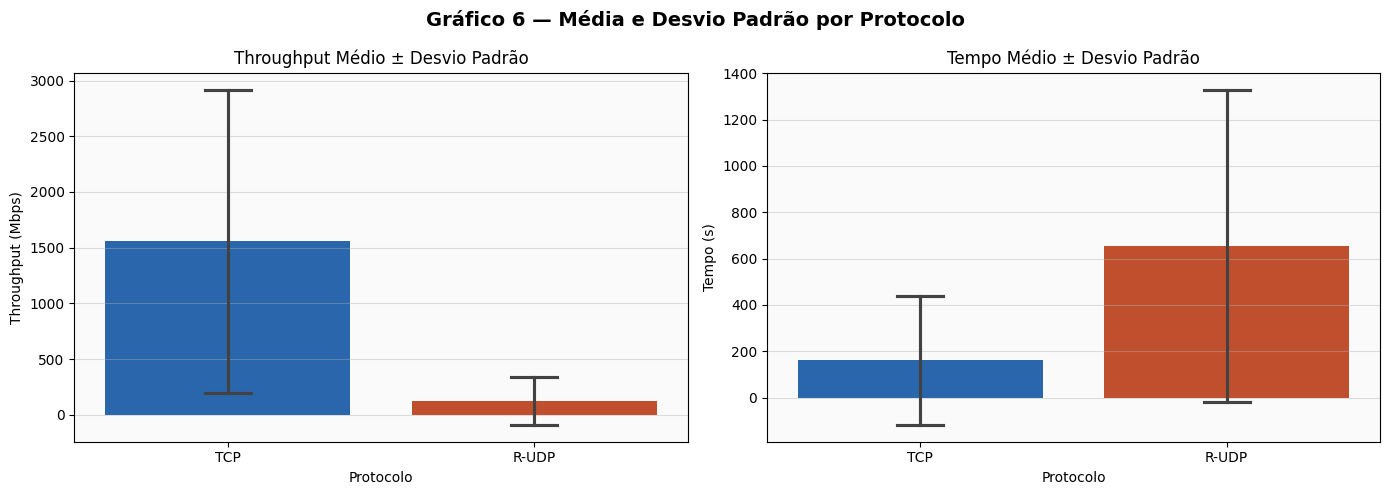

Salvo: graficos/grafico6_media_desvio.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gráfico 6 — Média e Desvio Padrão por Protocolo', fontsize=14, fontweight='bold')

cores = {'TCP': '#1565C0', 'R-UDP': '#D84315'}

# Throughput
sns.barplot(
    data=df, x='protocolo', y='throughput_mbps',
    palette=cores, capsize=0.15, errorbar='sd',
    ax=axes[0]
)
axes[0].set_title('Throughput Médio ± Desvio Padrão', fontsize=12)
axes[0].set_xlabel('Protocolo')
axes[0].set_ylabel('Throughput (Mbps)')
axes[0].grid(axis='y', alpha=0.4)
axes[0].set_facecolor('#FAFAFA')

# Tempo
sns.barplot(
    data=df, x='protocolo', y='duracao_s',
    palette=cores, capsize=0.15, errorbar='sd',
    ax=axes[1]
)
axes[1].set_title('Tempo Médio ± Desvio Padrão', fontsize=12)
axes[1].set_xlabel('Protocolo')
axes[1].set_ylabel('Tempo (s)')
axes[1].grid(axis='y', alpha=0.4)
axes[1].set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('graficos/grafico6_media_desvio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: graficos/grafico6_media_desvio.png')

## Célula 10 — Gráfico 7: Heatmap de Métricas (Seaborn)

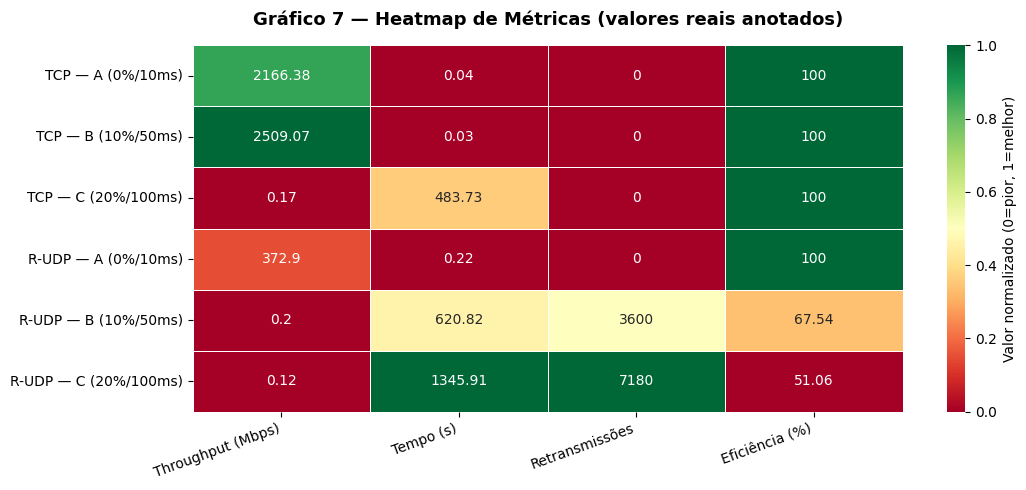

Salvo: graficos/grafico7_heatmap.png


In [ ]:
heatmap_df = df[['protocolo','cenario_label',
                 'throughput_mbps','duracao_s',
                 'retransmissoes','eficiencia_pct']].copy()
heatmap_df.index = heatmap_df['protocolo'] + ' — ' + heatmap_df['cenario_label']
heatmap_df = heatmap_df.drop(columns=['protocolo','cenario_label'])
heatmap_df.columns = ['Throughput (Mbps)', 'Tempo (s)', 'Retransmissões', 'Eficiência (%)']

# Normaliza para o heatmap
heatmap_norm = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_df.round(2),
    fmt='g',
    cmap='RdYlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Valor normalizado (0=pior, 1=melhor)'}
)
ax.set_title('Gráfico 7 — Heatmap de Métricas (valores reais anotados)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('graficos/grafico7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo: graficos/grafico7_heatmap.png')

## Célula 11 — Gráfico 8: Dashboard Completo (Plotly)

In [ ]:
fig8 = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Throughput (Mbps)',
        'Tempo de Transferência (s) — log',
        'Retransmissões R-UDP',
        'Eficiência (%)'
    ]
)

cores = {'TCP': '#1565C0', 'R-UDP': '#D84315'}

for proto in ['TCP', 'R-UDP']:
    d = df[df['protocolo'] == proto]
    first = (proto == 'TCP')

    fig8.add_trace(go.Bar(
        x=d['cenario_label'], y=d['throughput_mbps'],
        name=proto, marker_color=cores[proto],
        legendgroup=proto, showlegend=first
    ), row=1, col=1)

    fig8.add_trace(go.Bar(
        x=d['cenario_label'], y=d['duracao_s'],
        name=proto, marker_color=cores[proto],
        legendgroup=proto, showlegend=False
    ), row=1, col=2)

    fig8.add_trace(go.Bar(
        x=d['cenario_label'], y=d['eficiencia_pct'],
        name=proto, marker_color=cores[proto],
        legendgroup=proto, showlegend=False
    ), row=2, col=2)

d_rudp = df[df['protocolo'] == 'R-UDP']
fig8.add_trace(go.Bar(
    x=d_rudp['cenario_label'], y=d_rudp['retransmissoes'],
    name='R-UDP', marker_color='#D84315',
    legendgroup='R-UDP', showlegend=False
), row=2, col=1)

fig8.update_yaxes(type='log', row=1, col=2)
fig8.update_layout(
    height=700,
    title_text='<b>Gráfico 8 — Dashboard Completo: TCP vs R-UDP (PPGCC/UFPI 2026-1)</b>',
    barmode='group', font_size=11,
    plot_bgcolor='white'
)
fig8.show()
salvar_plotly(fig1, 'grafico1_throughput.png')
print('Salvo: graficos/grafico8_dashboard.png')

Salvo: graficos/grafico1_throughput.html
Salvo: graficos/grafico8_dashboard.png


## Célula 12 — Estatísticas completas

In [ ]:
stats = df.groupby('protocolo').agg(
    throughput_medio  =('throughput_mbps', 'mean'),
    throughput_std    =('throughput_mbps', 'std'),
    throughput_min    =('throughput_mbps', 'min'),
    throughput_max    =('throughput_mbps', 'max'),
    tempo_medio       =('duracao_s', 'mean'),
    tempo_std         =('duracao_s', 'std'),
    retransmissoes_total=('retransmissoes', 'sum'),
    eficiencia_media  =('eficiencia_pct', 'mean'),
    eficiencia_min    =('eficiencia_pct', 'min'),
).round(3)

print('=' * 60)
print('ESTATÍSTICAS POR PROTOCOLO (todos os cenários)')
print('=' * 60)
print(stats.T.to_string())
print()
print('=' * 60)
print('TABELA COMPLETA DE RESULTADOS')
print('=' * 60)
print(df[['protocolo','cenario_label','duracao_s','throughput_mbps',
          'retransmissoes','eficiencia_pct']].to_string(index=False))

ESTATÍSTICAS POR PROTOCOLO (todos os cenários)
protocolo                 R-UDP       TCP
throughput_medio        124.407  1558.540
throughput_std          215.201  1360.422
throughput_min            0.122     0.170
throughput_max          372.900  2509.070
tempo_medio             655.651   161.267
tempo_std               673.516   279.260
retransmissoes_total  10780.000     0.000
eficiencia_media         72.867   100.000
eficiencia_min           51.060   100.000

TABELA COMPLETA DE RESULTADOS
protocolo cenario_label  duracao_s  throughput_mbps  retransmissoes  eficiencia_pct
      TCP   A (0%/10ms)     0.0387         2166.380               0          100.00
      TCP  B (10%/50ms)     0.0334         2509.070               0          100.00
      TCP C (20%/100ms)   483.7290            0.170               0          100.00
    R-UDP   A (0%/10ms)     0.2250          372.900               0          100.00
    R-UDP  B (10%/50ms)   620.8220            0.200            3600           67.5

## Célula 13 — Download dos gráficos

In [ ]:
import shutil
shutil.make_archive('graficos_redes', 'zip', 'graficos')

try:
    from google.colab import files
    files.download('graficos_redes.zip')
    print('Download iniciado!')
except:
    print('Arquivo salvo como: graficos_redes.zip')

print()
print('Graficos gerados:')
for f in sorted(os.listdir('graficos')):
    size = os.path.getsize(f'graficos/{f}') // 1024
    print(f'  {f} ({size} KB)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download iniciado!

Graficos gerados:
  grafico1_throughput.html (4460 KB)
  grafico2_tempo.html (4460 KB)
  grafico3_retransmissoes.html (4461 KB)
  grafico4_eficiencia.html (4460 KB)
  grafico6_media_desvio.png (65 KB)
  grafico7_heatmap.png (114 KB)
  rafico5_degradacao.html (4460 KB)


## Conclusões

| Observação | Detalhe |
|---|---|
| TCP Cenários A e B | Throughput > 2000 Mbps — kernel Linux otimiza retransmissões internamente |
| TCP Cenário C | Degradação severa (483s) com 20% de perda — algoritmo CUBIC reduz janela |
| R-UDP Cenário A | 372 Mbps sem perdas — overhead do protocolo customizado com janela N=4 |
| R-UDP Cenários B e C | Degradação extrema (620s e 1345s) — Go-Back-N retransmite janela inteira |
| Eficiência R-UDP | Cai para 51% no Cenário C — metade dos bytes são retransmissões |
| MD5 do arquivo | Idêntico em todos os cenários — entrega íntegra comprovada |

**Conclusão principal:** O R-UDP com janela Go-Back-N de tamanho N=4 é muito sensível à perda de pacotes. O Selective Repeat ou janela adaptativa melhoraria significativamente o desempenho nos cenários B e C.